# Análisis estructural de la red PPI de *Arabidopsis thaliana*
**Biología de Sistemas — Práctica 1**  
Datos exportados desde Cytoscape (Network Analyzer) → `node_table_p1.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy import stats

In [2]:
# --- Rutas de los archivos exportados desde Cytoscape ---
CSV_RED_COMPLETA = "node_table_p1.csv"        # Red PPI completa de A. thaliana
CSV_SUBRED       = "subred_node_table.csv"    # Subred (ego network de AT5G22290)
CSV_MCL          = "merged_network_clustered.csv"  # Red fusionada con clusters MCL

# --- Carga de datos ---
df     = pd.read_csv(CSV_RED_COMPLETA)
sub    = pd.read_csv(CSV_SUBRED)
df_mcl = pd.read_csv(CSV_MCL)

print(f"Red completa (A. thaliana PPI): {len(df)} nodos")
print(f"Subred (ego network):           {len(sub)} nodos")
print(f"Red fusionada (enfermedades):   {len(df_mcl)} nodos")
df.head(3)

Red completa (A. thaliana PPI): 4866 nodos
Subred (ego network):           270 nodos
Red fusionada (enfermedades):   257 nodos


,AverageShortestPathLength,BetweennessCentrality,ClosenessCentrality,ClusteringCoefficient,Degree,Eccentricity,IsSingleNode,name,NeighborhoodConnectivity,NumberOfDirectedEdges,NumberOfUndirectedEdges,PartnerOfMultiEdgedNodePairs,Radiality,selected,SelfLoops,shared name,Stress,TopologicalCoefficient
0,7.215582,0.000000e+00,0.138589,0.000000,1,12,False,AT5G62390,2.000000,0,1,0,0.976894,False,0,AT5G62390,0,0.000000
1,6.287295,4.900086e-08,0.159051,0.666667,5,12,False,AT2G40950,3.333333,0,4,0,0.980345,False,1,AT2G40950,2,0.555556
2,6.287517,0.000000e+00,0.159045,1.000000,2,12,False,AT1G42990,4.500000,0,2,0,0.980344,False,0,AT1G42990,0,0.750000


## 1. Distribución de grado
Representación lineal y log-log con ajuste de ley de potencias.

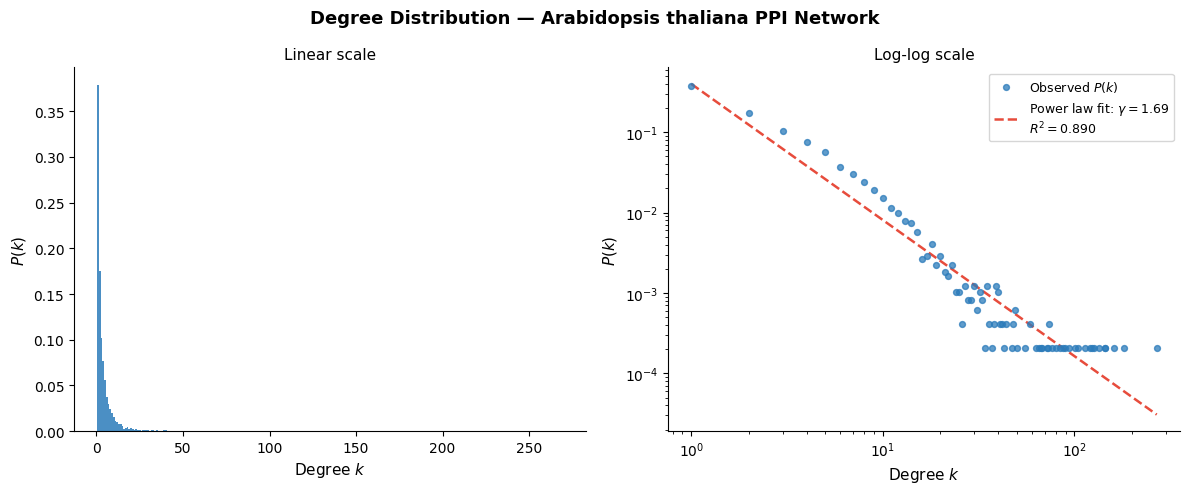

γ = 1.693 | R² = 0.890


In [3]:
degrees = df["Degree"].astype(int)
N = len(degrees)

degree_counts = Counter(degrees)
k_values = np.array(sorted(degree_counts.keys()))
pk_values = np.array([degree_counts[k] / N for k in k_values])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Degree Distribution — Arabidopsis thaliana PPI Network", fontsize=13, fontweight="bold")

# Lineal
axes[0].bar(k_values, pk_values, color="#2b7bba", width=1.0, alpha=0.85)
axes[0].set_xlabel("Degree $k$", fontsize=11)
axes[0].set_ylabel("$P(k)$", fontsize=11)
axes[0].set_title("Linear scale", fontsize=11)
axes[0].spines[["top", "right"]].set_visible(False)

# Log-log con ajuste
log_k = np.log10(k_values[k_values > 0])
log_pk = np.log10(pk_values[k_values > 0])
slope, intercept, r, _, _ = stats.linregress(log_k, log_pk)
k_fit = np.linspace(k_values.min(), k_values.max(), 200)
pk_fit = 10**intercept * k_fit**slope

axes[1].scatter(k_values, pk_values, color="#2b7bba", s=18, alpha=0.75, zorder=3, label="Observed $P(k)$")
axes[1].plot(k_fit, pk_fit, color="#e74c3c", linewidth=1.8, linestyle="--",
             label=f"Power law fit: $\\gamma = {-slope:.2f}$\n$R^2 = {r**2:.3f}$")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Degree $k$", fontsize=11)
axes[1].set_ylabel("$P(k)$", fontsize=11)
axes[1].set_title("Log-log scale", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("degree_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"γ = {-slope:.3f} | R² = {r**2:.3f}")

## 2. Hubs — nodos con grado > 100

In [4]:
hubs_100 = df[df["Degree"] > 100][["name", "Degree", "BetweennessCentrality", "ClusteringCoefficient"]]\
    .sort_values("Degree", ascending=False).reset_index(drop=True)
hubs_100.columns = ["Nodo", "Grado", "Betweenness Centrality", "Clustering Coefficient"]
hubs_100["Betweenness Centrality"] = hubs_100["Betweenness Centrality"].round(4)
hubs_100["Clustering Coefficient"] = hubs_100["Clustering Coefficient"].round(4)
print(f"Nodos con grado > 100: {len(hubs_100)}")
hubs_100

Nodos con grado > 100: 12


,Nodo,Grado,Betweenness Centrality,Clustering Coefficient
0,AT5G22290,269,0.0921,0.0044
1,AT4G19030,181,0.0210,0.0040
2,AT4G35580,161,0.0328,0.0050
3,AT3G47620,145,0.0843,0.0070
4,AT1G22920,144,0.0960,0.0029
5,AT1G78300,134,0.0788,0.0030
6,AT1G27300,126,0.0127,0.0193
7,AT1G66410,123,0.0215,0.0021
8,AT3G43810,120,0.0193,0.0155
9,AT3G51920,114,0.0110,0.0175


## 3. Correlaciones en nodos con mayor grado (Degree ≥ 20)
Se analizan las correlaciones entre grado y otras propiedades topológicas en el subconjunto de nodos más conectados (top 8.5% de la red).

Nodos con grado ≥ 20: 152


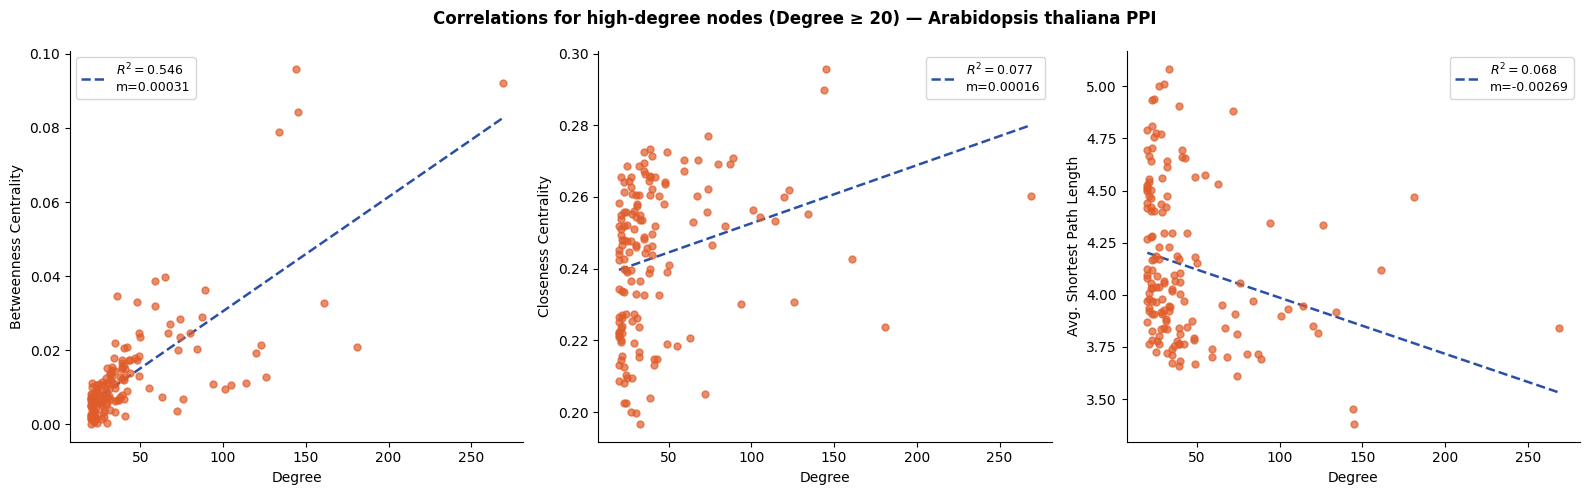

In [5]:
hubs = df[df["Degree"] >= 20].copy()
print(f"Nodos con grado ≥ 20: {len(hubs)}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Correlations for high-degree nodes (Degree ≥ 20) — Arabidopsis thaliana PPI",
             fontsize=12, fontweight="bold")

plots = [
    ("Degree", "BetweennessCentrality", "Betweenness Centrality"),
    ("Degree", "ClosenessCentrality", "Closeness Centrality"),
    ("Degree", "AverageShortestPathLength", "Avg. Shortest Path Length"),
]

for ax, (x_col, y_col, y_label) in zip(axes, plots):
    x = hubs[x_col]
    y = hubs[y_col]
    ax.scatter(x, y, color="#e05c2a", s=25, alpha=0.7, zorder=3)
    slope, intercept, r, _, _ = stats.linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_fit, slope * x_fit + intercept, color="#2b4fa8", linewidth=1.8, linestyle="--",
            label=f"$R^2={r**2:.3f}$\nm={slope:.5f}")
    ax.set_xlabel("Degree", fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("scatter_hubs.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Matriz de correlación de Pearson (nodos con Degree ≥ 20)

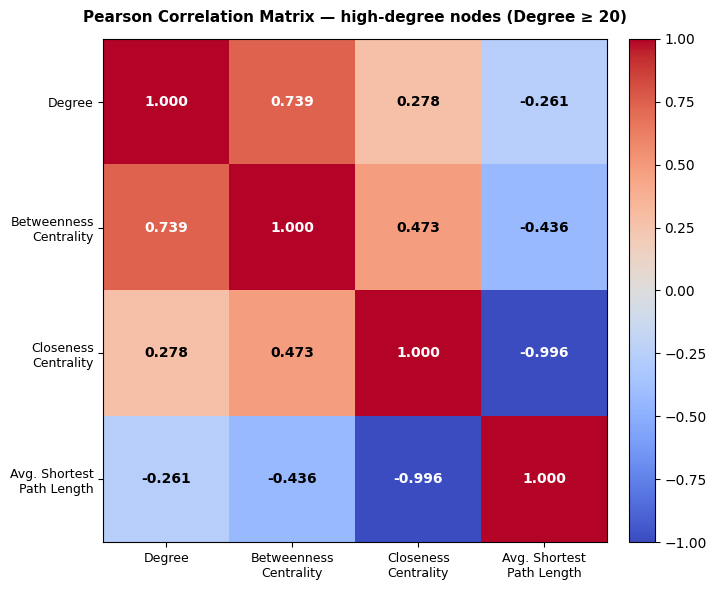


Matriz de correlación:
                            Degree  Betweenness\nCentrality  \
Degree                       1.000                    0.739   
Betweenness\nCentrality      0.739                    1.000   
Closeness\nCentrality        0.278                    0.473   
Avg. Shortest\nPath Length  -0.261                   -0.436   

                            Closeness\nCentrality  Avg. Shortest\nPath Length  
Degree                                      0.278                      -0.261  
Betweenness\nCentrality                     0.473                      -0.436  
Closeness\nCentrality                       1.000                      -0.996  
Avg. Shortest\nPath Length                 -0.996                       1.000  


In [6]:
cols = {
    "Degree": "Degree",
    "BetweennessCentrality": "Betweenness\nCentrality",
    "ClosenessCentrality": "Closeness\nCentrality",
    "AverageShortestPathLength": "Avg. Shortest\nPath Length",
}

corr_df = hubs[list(cols.keys())].rename(columns=cols).corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_df, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

labels = list(cols.values())
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_df.iloc[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=10, color=color, fontweight="bold")

ax.set_title("Pearson Correlation Matrix — high-degree nodes (Degree ≥ 20)", fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nMatriz de correlación:")
print(corr_df.round(3))

## 5. Coeficiente de agrupamiento (CC) vs Grado — subred (ego network)

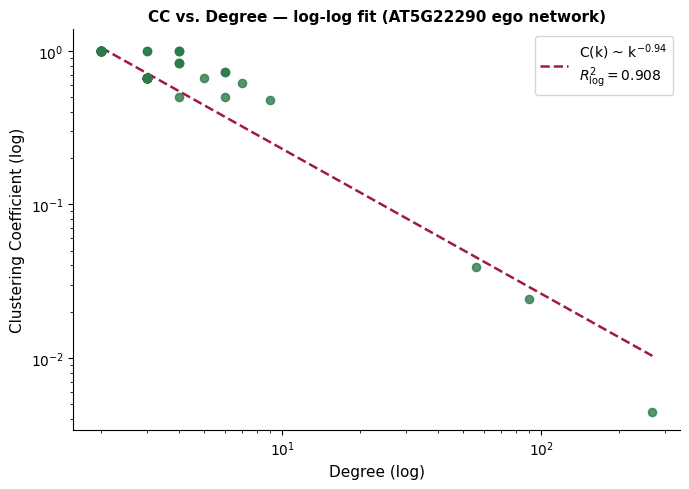

In [7]:
# Nodos con CC > 0 y Degree > 1 para el ajuste log-log
sub_nz = sub[(sub["ClusteringCoefficient"] > 0) & (sub["Degree"] > 1)].copy()

log_k = np.log10(sub_nz["Degree"])
log_cc = np.log10(sub_nz["ClusteringCoefficient"])
slope, intercept, r_log, _, _ = stats.linregress(log_k, log_cc)
k_fit = np.linspace(log_k.min(), log_k.max(), 200)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sub_nz["Degree"], sub_nz["ClusteringCoefficient"],
           color="#2b7a4a", s=35, alpha=0.8, zorder=3)
ax.plot(10**k_fit, 10**(slope * k_fit + intercept),
        color="#a01c3e", linewidth=1.8, linestyle="--",
        label=f"C(k) ~ k$^{{{slope:.2f}}}$\n$R^2_{{\\mathrm{{log}}}}={r_log**2:.3f}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Degree (log)", fontsize=11)
ax.set_ylabel("Clustering Coefficient (log)", fontsize=11)
ax.set_title("CC vs. Degree — log-log fit (AT5G22290 ego network)", fontsize=11, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("scatter_cc.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Matriz de correlación de Spearman (subred, CC > 0)

Nodos con CC > 0: 116


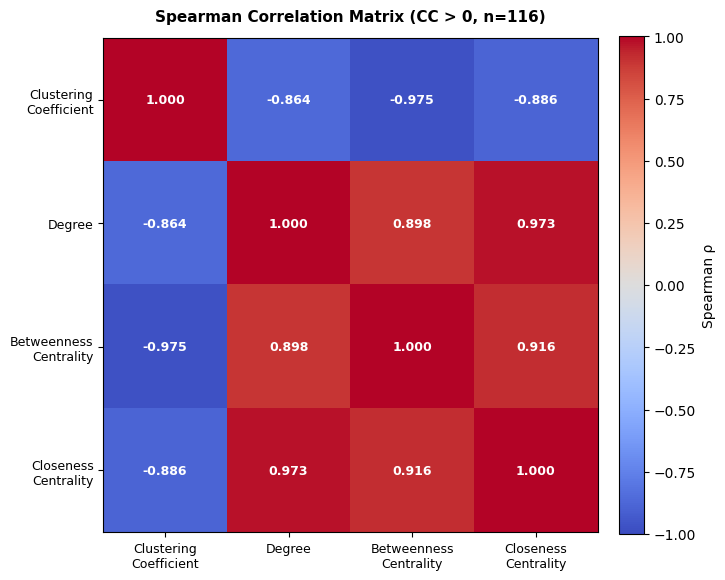

In [8]:
# Nodos con CC > 0 (excluye hojas que distorsionan los rangos)
sub_nz = sub[sub["ClusteringCoefficient"] > 0].copy()
print(f"Nodos con CC > 0: {len(sub_nz)}")

cols_cc = {
    "ClusteringCoefficient":  "Clustering\nCoefficient",
    "Degree":                 "Degree",
    "BetweennessCentrality":  "Betweenness\nCentrality",
    "ClosenessCentrality":    "Closeness\nCentrality",
}

keys = list(cols_cc.keys())
labels_cc = list(cols_cc.values())
n = len(keys)

# Construir matriz de Spearman manualmente
spearman_matrix = np.zeros((n, n))
pval_matrix = np.zeros((n, n))
for i, ci in enumerate(keys):
    for j, cj in enumerate(keys):
        rho, pval = stats.spearmanr(sub_nz[ci], sub_nz[cj])
        spearman_matrix[i, j] = rho
        pval_matrix[i, j] = pval

df_sp = pd.DataFrame(spearman_matrix, index=labels_cc, columns=labels_cc)

# Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(spearman_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman ρ")

ax.set_xticks(range(n)); ax.set_xticklabels(labels_cc, fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(labels_cc, fontsize=9)

for i in range(n):
    for j in range(n):
        rho_val = spearman_matrix[i, j]
        sig = "" if pval_matrix[i, j] < 0.001 else ("†" if pval_matrix[i, j] < 0.05 else " n.s.")
        text_color = "white" if abs(rho_val) > 0.6 else "black"
        ax.text(j, i, f"{rho_val:.3f}{sig}", ha="center", va="center",
                fontsize=9, color=text_color, fontweight="bold")

ax.set_title(f"Spearman Correlation Matrix (CC > 0, n={len(sub_nz)})",
             fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("spearman_cc_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


## 7. Clustering MCL — Red de enfermedades (Tarea 2)
Análisis de los clusters generados por el algoritmo MCL (inflación = 5) sobre la red fusionada de 257 nodos exportada desde Cytoscape (`merged_network_clustered.csv`).  
Se identifican los clusters con más de 10 nodos y se evalúa la composición por enfermedad.

In [9]:
print(f"Nodos totales: {len(df_mcl)}")
print(f"Nodos sin cluster asignado (NaN): {df_mcl['__mclCluster'].isna().sum()}")
print(f"Número de clusters: {int(df_mcl['__mclCluster'].nunique())}")

cluster_sizes = df_mcl['__mclCluster'].value_counts().sort_values(ascending=False)
print("\nTamaño de todos los clusters:")
print(cluster_sizes.to_string())

big = cluster_sizes[cluster_sizes > 10]
print(f"\nClusters con más de 10 nodos ({len(big)}):")
print(big.to_string())

Nodos totales: 257
Nodos sin cluster asignado (NaN): 49
Número de clusters: 42

Tamaño de todos los clusters:
__mclCluster
1.0     25
2.0     20
3.0     13
4.0     12
5.0     10
6.0     10
7.0      9
8.0      7
9.0      7
10.0     6
11.0     6
12.0     6
13.0     5
14.0     5
17.0     4
18.0     4
16.0     4
15.0     4
19.0     3
20.0     3
21.0     3
32.0     2
41.0     2
40.0     2
39.0     2
38.0     2
37.0     2
36.0     2
35.0     2
34.0     2
33.0     2
22.0     2
31.0     2
30.0     2
29.0     2
28.0     2
27.0     2
26.0     2
25.0     2
24.0     2
23.0     2
42.0     2

Clusters con más de 10 nodos (4):
__mclCluster
1.0    25
2.0    20
3.0    13
4.0    12


In [10]:
diseases = ['Anxiety disorder', 'Pancreatic cancer', 'Sleep disorder']
big_clusters = [int(c) for c in cluster_sizes[cluster_sizes > 10].index]

for c in big_clusters:
    cluster_sub = df_mcl[df_mcl['__mclCluster'] == c]
    print(f"\n{'='*60}")
    print(f"Cluster {c}  ({len(cluster_sub)} nodos)")
    print(f"Proteínas: {', '.join(cluster_sub['display name'].tolist())}")
    for d in diseases:
        n_with = cluster_sub[d].notna().sum()
        pct = 100 * n_with / len(cluster_sub)
        print(f"  {d:25s}: {n_with:2d}/{len(cluster_sub)}  ({pct:.0f} %)")


Cluster 1  (25 nodos)
Proteínas: POLI, PALB2, PIK3CD, PIK3CB, STK11, CDKN2A, BRCA2, BIRC5, PIK3CA, PARP1, ATM, BRCA1, CDK4, PTEN, SMAD4, MYC, STAT3, ANXA5, CCND1, ACTB, GAPDH, TP53, PIK3C2A, JUN, AIF1
  Anxiety disorder         :  2/25  (8 %)
  Pancreatic cancer        : 22/25  (88 %)
  Sleep disorder           :  3/25  (12 %)

Cluster 2  (20 nodos)
Proteínas: GPX6, GPX5, ISG15, IFNG, IL10, IL2, CSF2, TGFB1, CXCL8, CCL2, CXCL12, PXDNL, PXDN, MMP9, TNFRSF1B, TNF, IL6, IL1B, TLR4, NFKB1
  Anxiety disorder         :  6/20  (30 %)
  Pancreatic cancer        : 16/20  (80 %)
  Sleep disorder           :  6/20  (30 %)

Cluster 3  (13 nodos)
Proteínas: BCAR1, MUC1, MSLN, CEACAM5, EGFR, GPC1, IGF1R, FGF2, ERBB2, MET, EGF, CXCR4, FN1
  Anxiety disorder         :  0/13  (0 %)
  Pancreatic cancer        : 13/13  (100 %)
  Sleep disorder           :  0/13  (0 %)

Cluster 4  (12 nodos)
Proteínas: OPN4, PER3, PER2, ARNTL, CLOCK, CRY2, NPAS2, CSNK1D, NR1D1, RORB, TEF, CRY1
  Anxiety disorder         